# pybalmorel for Post-Processing
This notebook provide examples on how to use pybalmorel for pre-processing, post-processing and for executing Balmorel scenarios. Check the following pages:
- [Home](../README.md)
- [Pre-Processing](PreProcessing.ipynb)
- [Execution](Execution.ipynb)

In [11]:
import os
import pandas as pd
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Adjust the sys.path to include the project root directory
project_root = os.path.abspath(os.path.join(os.path.dirname("__file__"), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from src.pybalmorel import MainResults
from src.pybalmorel.plotting import plot_functions as pf

gams_system_directory = "/Library/Frameworks/GAMS.framework/Versions/54/Resources/"

In [41]:
### 1.1.2 Loading several scenarios
res = MainResults(files=['MainResults_NZwoCCS.gdx',
                         'MainResults_NZwoCCS_v2.gdx',
                        'MainResults_NZwCCS.gdx',
                        'MainResults_NZwCCS_v2.gdx',
                        'MainResults_CO2TaxwCCS_S26.gdx',
                        'MainResults_NNwCCS.gdx',
                        'MainResults_NNwCCS_v3.gdx'],
                    paths=['Balmorel/02Project_NZwithoutCCS/Model',
                           'Balmorel/02Project_NZwithoutCCS_S26/Model',
                            'Balmorel/03Project_NZwCCS/Model',
                            'Balmorel/03Project_NZwCCS_S26/Model',
                            'Balmorel/04Project_CO2TaxwCCS_S26/Model',
                            'Balmorel/05Project_NNwCCS/Model',
                            'Balmorel/05Project_NNwCCS_S26/Model'],
                    scenario_names=['Net-Zero w/o CCS', 'Net-Zero w/o CCS s26', 'Net-Zero w CCS', 'Net-Zero w CCS s26', 'CO2 Tax w CCS s26', 'Net-Negative w CCS', 'Net-Negative w CCS s26'],
                    system_directory=gams_system_directory)


Loading Balmorel/02Project_NZwithoutCCS/Model/MainResults_NZwoCCS.gdx
Loading Balmorel/02Project_NZwithoutCCS_S26/Model/MainResults_NZwoCCS_v2.gdx
Loading Balmorel/03Project_NZwCCS/Model/MainResults_NZwCCS.gdx
Loading Balmorel/03Project_NZwCCS_S26/Model/MainResults_NZwCCS_v2.gdx
Loading Balmorel/04Project_CO2TaxwCCS_S26/Model/MainResults_CO2TaxwCCS_S26.gdx
Loading Balmorel/05Project_NNwCCS/Model/MainResults_NNwCCS.gdx
Loading Balmorel/05Project_NNwCCS_S26/Model/MainResults_NNwCCS_v3.gdx


In [42]:
F_CONS_YCRAT = pd.DataFrame(res.get_result('F_CONS_YCRAST'))
PRO_YCRAGF = pd.DataFrame(res.get_result('PRO_YCRAGF'))
G_CAP_YCRAF = pd.DataFrame(res.get_result('G_CAP_YCRAF'))
EMI_YCRAG = pd.DataFrame(res.get_result('EMI_YCRAG'))

# filtering the biomass
PRO_YCRAGF_bio = PRO_YCRAGF[PRO_YCRAGF['Fuel'].str.contains('WOOD', case=False, na=False) | PRO_YCRAGF['Fuel'].str.contains('STRAW', case=False, na=False)]
F_CONS_YCRAT_bio = F_CONS_YCRAT[F_CONS_YCRAT['Fuel'].str.contains('WOOD', case=False, na=False) | F_CONS_YCRAT['Fuel'].str.contains('STRAW', case=False, na=False)]

Symbol contents are empty


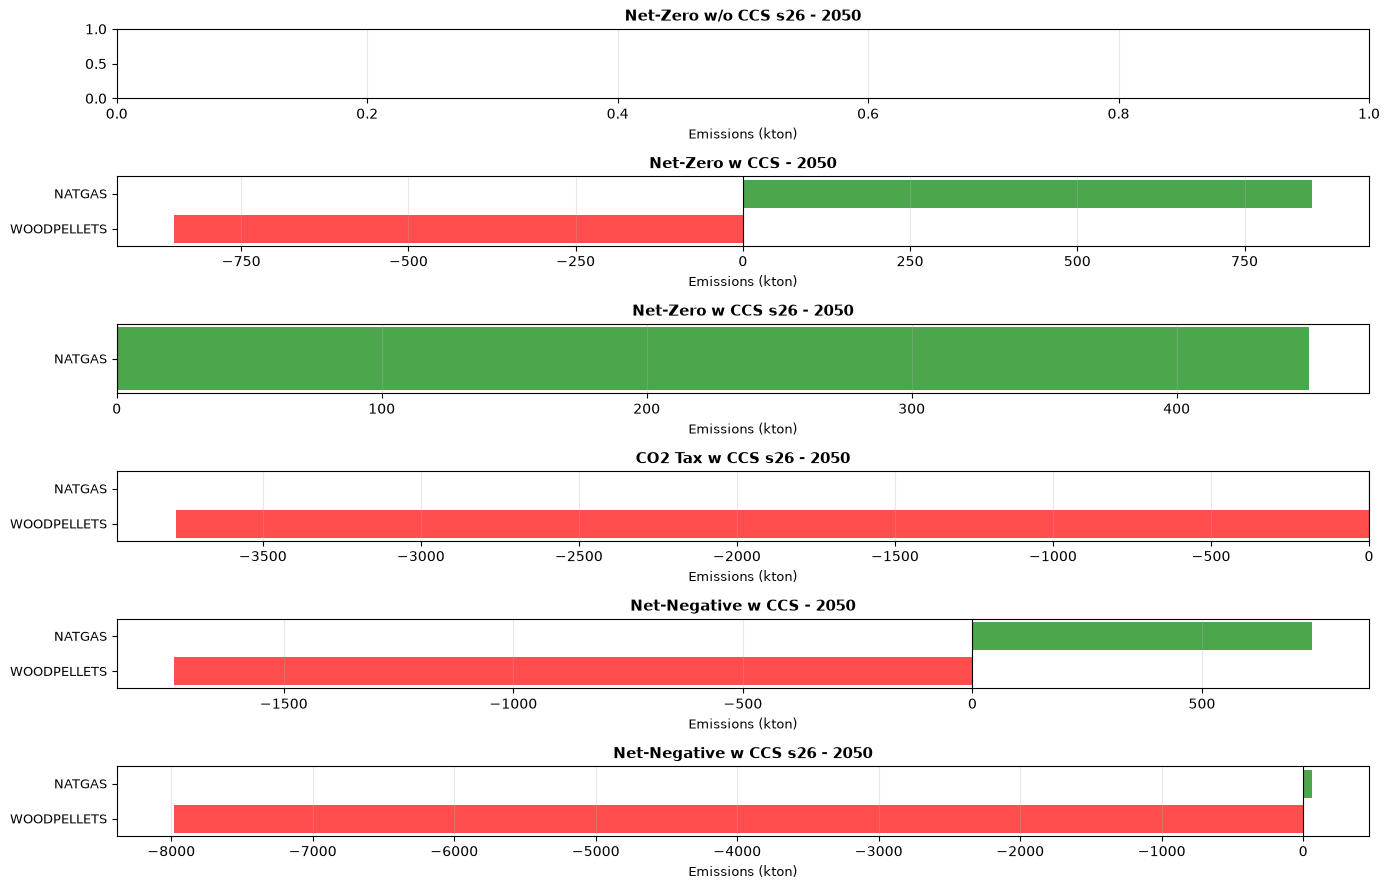

In [44]:
scenarios = [
    "Net-Zero w/o CCS s26",
    "Net-Zero w CCS",
    "Net-Zero w CCS s26",
    "CO2 Tax w CCS s26",
    "Net-Negative w CCS",
    "Net-Negative w CCS s26"
]
years = [2050]
fig, axes = pf.plot_emissions_grid_by_year_and_scenario(
    EMI_YCRAG, years=years, scenarios=scenarios
)

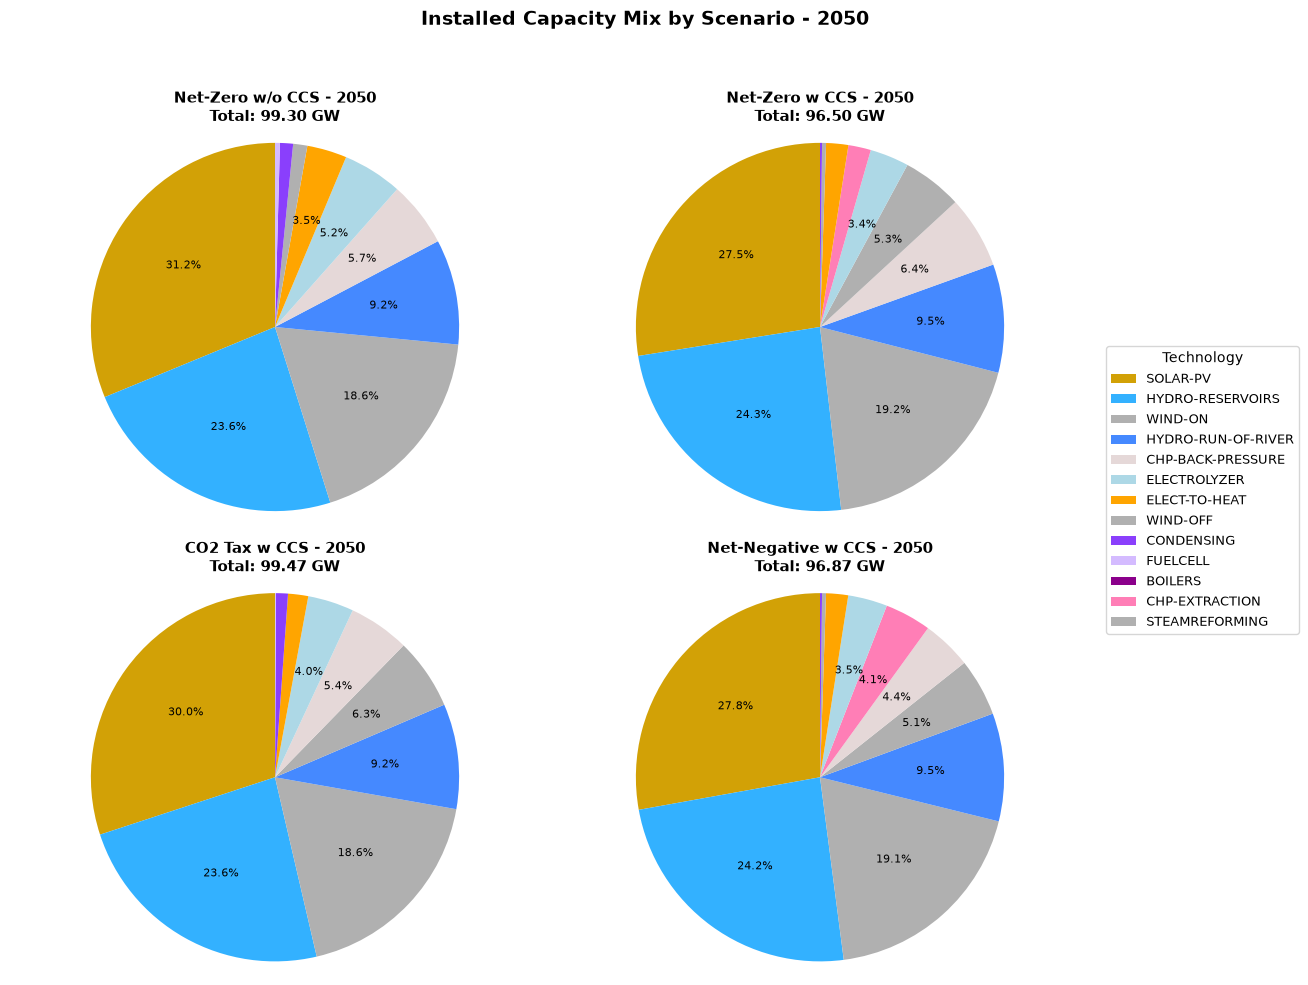

In [5]:
scenarios = [
    "Net-Zero w/o CCS",
    "Net-Zero w CCS",
    "CO2 Tax w CCS",
    "Net-Negative w CCS",
]

fig, ax = pf.plot_capacity_pie_by_scenario(
    G_CAP_YCRAF,
    year=2050,
    scenarios=scenarios,
    min_capacity=0.0,
)

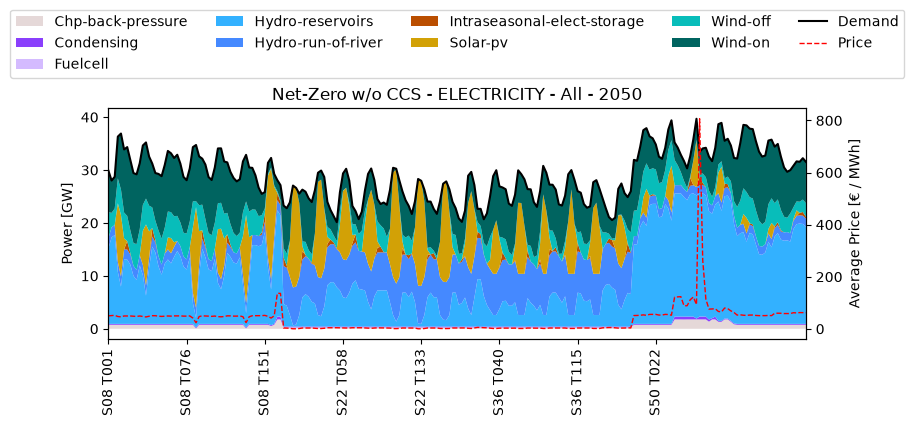

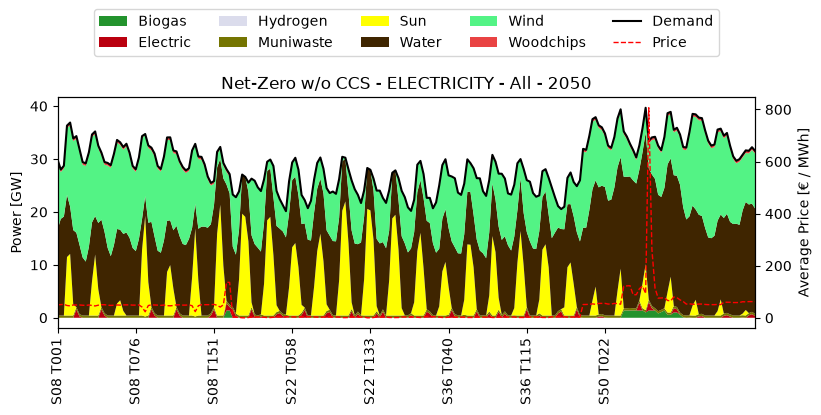

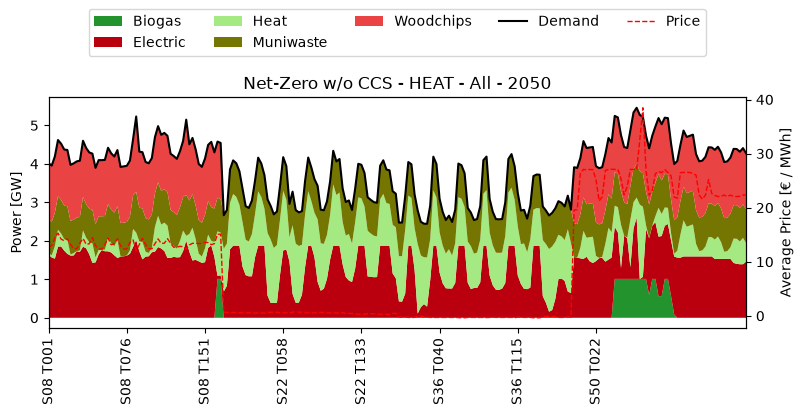

In [18]:
fig, ax = res.plot_profile(scenario='Net-Zero w/o CCS', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='Net-Zero w/o CCS', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='Net-Zero w/o CCS', year=2050, commodity='Heat', columns='Fuel')

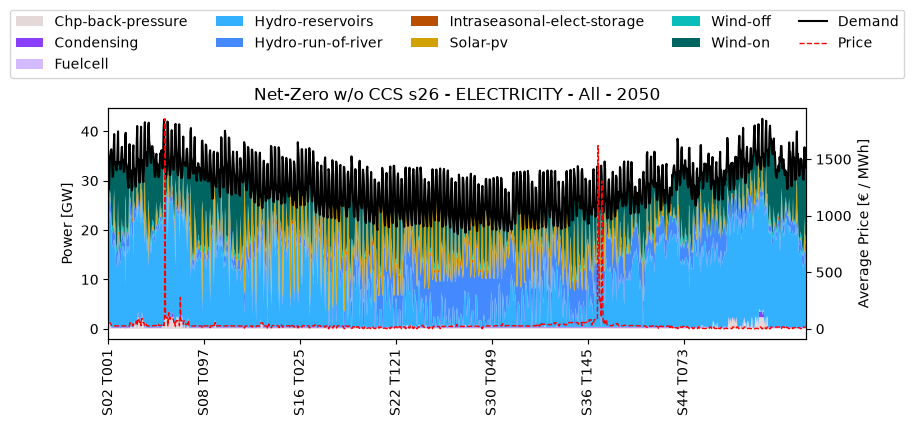

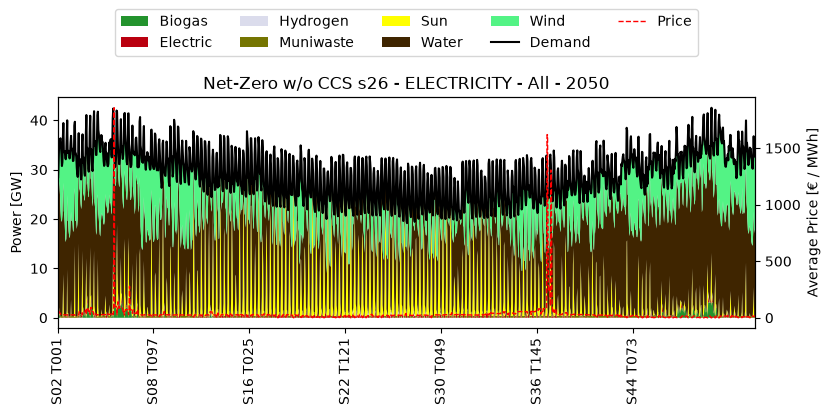

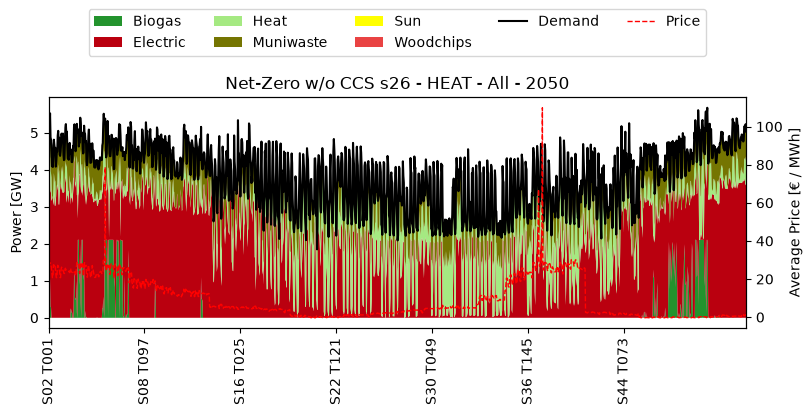

In [19]:
fig, ax = res.plot_profile(scenario='Net-Zero w/o CCS s26', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='Net-Zero w/o CCS s26', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='Net-Zero w/o CCS s26', year=2050, commodity='Heat', columns='Fuel')

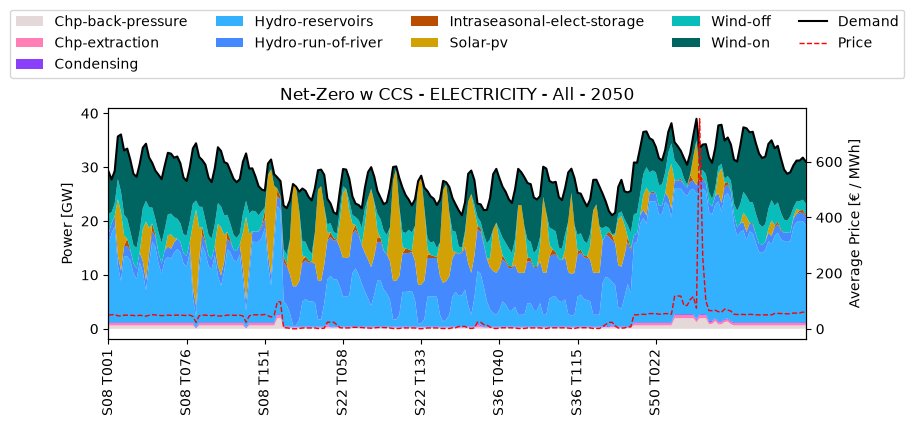

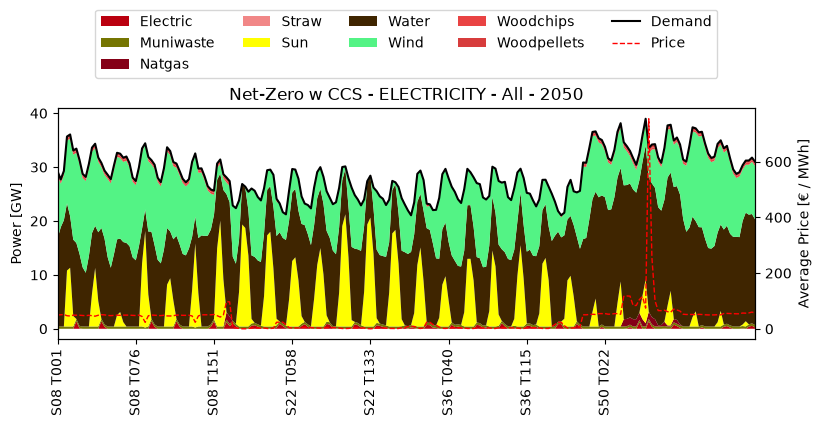

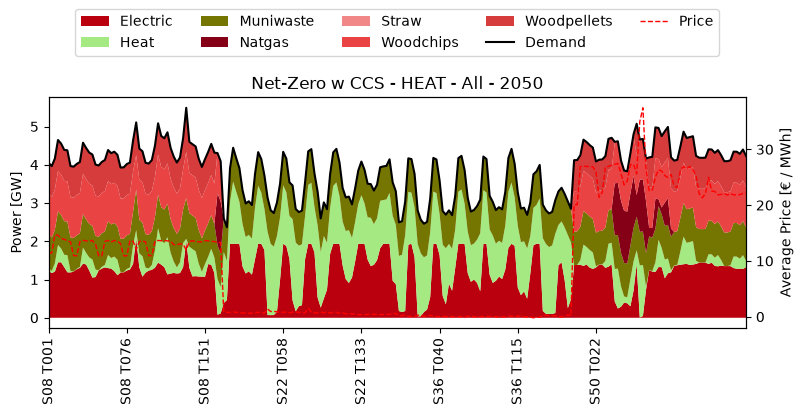

In [7]:
fig, ax = res.plot_profile(scenario='Net-Zero w CCS', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='Net-Zero w CCS', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='Net-Zero w CCS', year=2050, commodity='Heat', columns='Fuel')

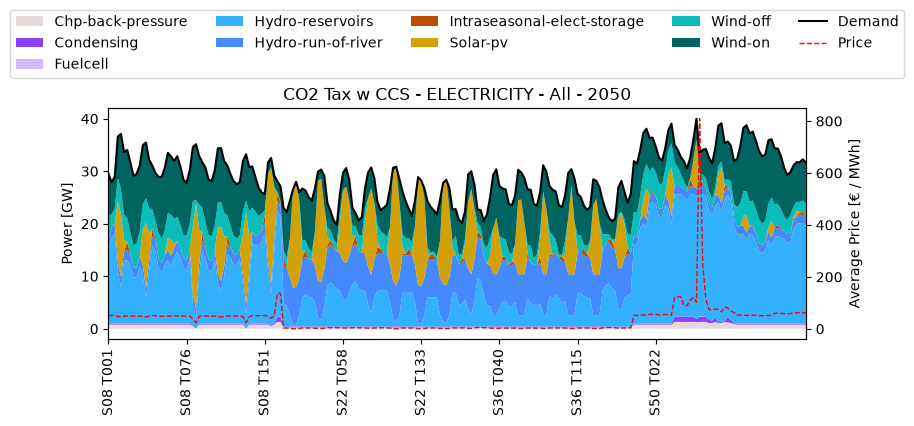

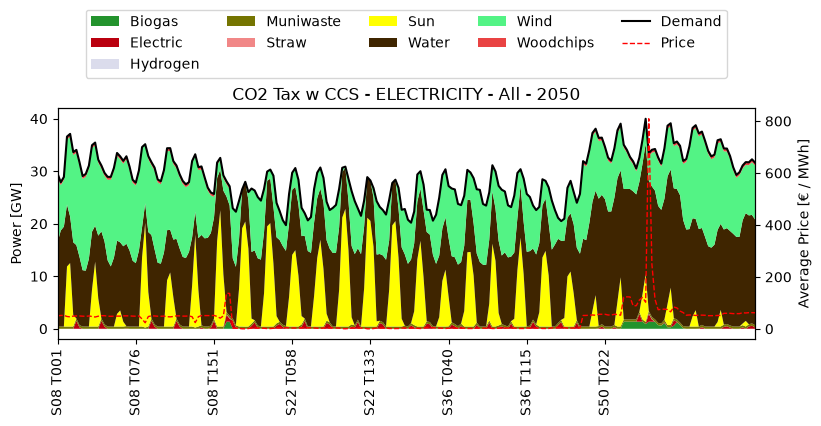

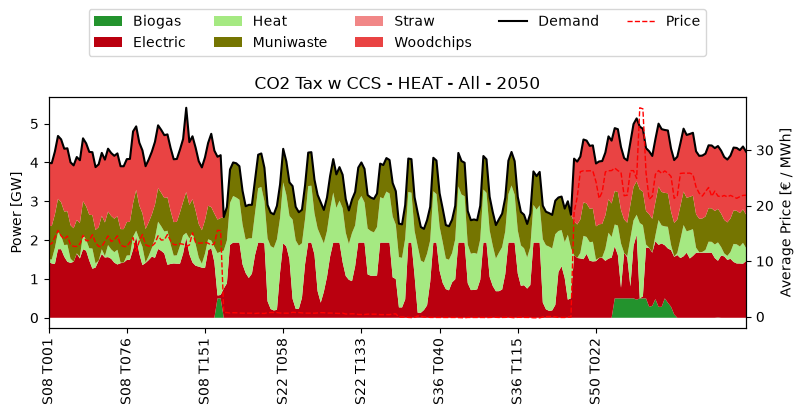

In [8]:
fig, ax = res.plot_profile(scenario='CO2 Tax w CCS', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='CO2 Tax w CCS', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='CO2 Tax w CCS', year=2050, commodity='Heat', columns='Fuel')

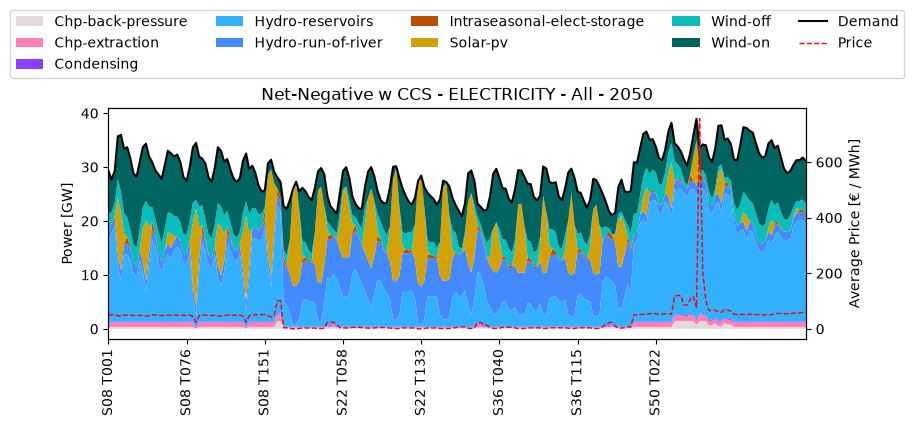

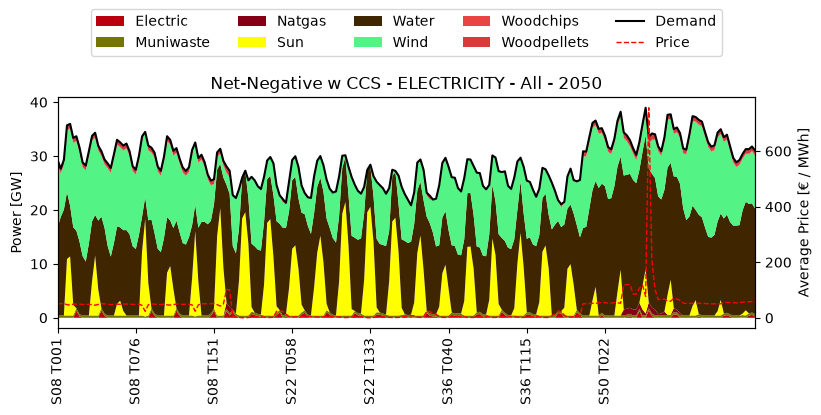

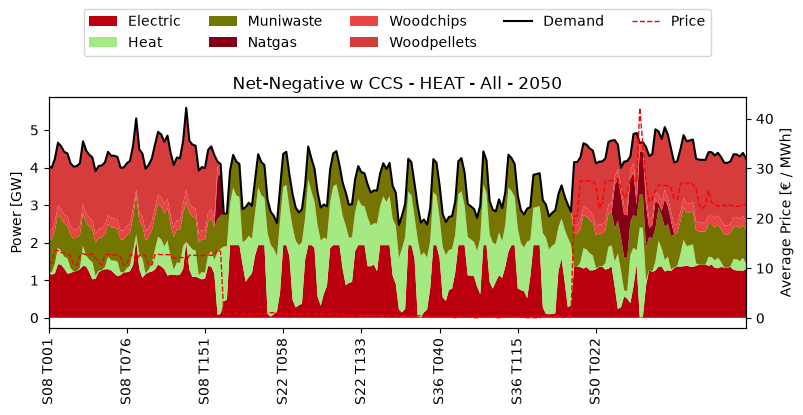

In [9]:
fig, ax = res.plot_profile(scenario='Net-Negative w CCS', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='Net-Negative w CCS', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='Net-Negative w CCS', year=2050, commodity='Heat', columns='Fuel')

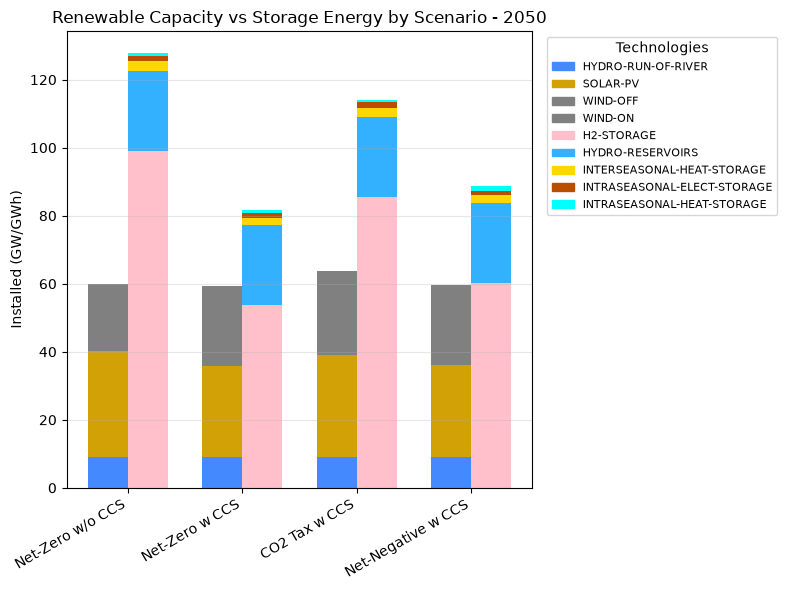

In [10]:
fig, ax = pf.plot_renewables_vs_storage_by_tech(G_CAP_YCRAF, year=2050, scenarios=["Net-Zero w/o CCS","Net-Zero w CCS","CO2 Tax w CCS","Net-Negative w CCS"], min_capacity=0.0)